# Imports

In [1]:
import math
import pickle
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import TargetEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# To prevent the output from being truncated
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

# Dataset

## Data Input

In [2]:
# Train dataset
df_train = pd.read_csv("train/train.csv")
df_train.head(5)

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


In [3]:
df_center = pd.read_csv("train/fulfilment_center_info.csv")
df_center.head(5)

,center_id,city_code,region_code,center_type,op_area
0,11,679,56,TYPE_A,3.7
1,13,590,56,TYPE_B,6.7
2,124,590,56,TYPE_C,4.0
3,66,648,34,TYPE_A,4.1
4,94,632,34,TYPE_C,3.6


In [4]:
df_meal = pd.read_csv("train/meal_info.csv")
df_meal.head(5)

,meal_id,category,cuisine
0,1885,Beverages,Thai
1,1993,Beverages,Thai
2,2539,Beverages,Thai
3,1248,Beverages,Indian
4,2631,Beverages,Indian


In [5]:
# Test dataset
df_test = pd.read_csv("test_QoiMO9B.csv")
df_test.head(5)

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured
0,1028232,146,55,1885,158.11,159.11,0,0
1,1127204,146,55,1993,160.11,159.11,0,0
2,1212707,146,55,2539,157.14,159.14,0,0
3,1082698,146,55,2631,162.02,162.02,0,0
4,1400926,146,55,1248,163.93,163.93,0,0


In [6]:
# Sample output
df_sample = pd.read_csv("sample_submission_hSlSoT6.csv")
df_sample.head(5)

,id,num_orders
0,1028232,0
1,1127204,0
2,1212707,0
3,1082698,0
4,1400926,0


## Merge datasets

In [7]:
# Join the data from fulfilment_center_info.csv and meal_info.csv into train and test datasets

df_train = pd.merge(df_train, df_center, on='center_id')
df_train = pd.merge(df_train, df_meal, on='meal_id')
df_train.drop(columns=['center_id','meal_id'], axis=1, inplace=True)

df_test = pd.merge(df_test, df_center, on='center_id')
df_test = pd.merge(df_test, df_meal, on='meal_id')
df_test.drop(columns=['center_id','meal_id'], axis=1, inplace=True)

print(df_train.head(20))
print(df_test.head(20))

         id  week  checkout_price  base_price  emailer_for_promotion  \
0   1379560     1          136.83      152.29                      0   
1   1466964     1          136.83      135.83                      0   
2   1346989     1          134.86      135.86                      0   
3   1338232     1          339.50      437.53                      0   
4   1448490     1          243.50      242.50                      0   
5   1270037     1          251.23      252.23                      0   
6   1191377     1          183.36      184.36                      0   
7   1499955     1          182.36      183.36                      0   
8   1025244     1          193.06      192.06                      0   
9   1054194     1          325.92      384.18                      0   
10  1469367     1          323.01      390.00                      0   
11  1029333     1          322.07      388.00                      0   
12  1446016     1          311.43      310.43                   

## Data Understanding

In [8]:
df_train.shape

(456548, 13)

After merging, dataset consists of **13 columns and 4,56,548 rows**

In [9]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   checkout_price         456548 non-null  float64
 3   base_price             456548 non-null  float64
 4   emailer_for_promotion  456548 non-null  int64  
 5   homepage_featured      456548 non-null  int64  
 6   num_orders             456548 non-null  int64  
 7   city_code              456548 non-null  int64  
 8   region_code            456548 non-null  int64  
 9   center_type            456548 non-null  object 
 10  op_area                456548 non-null  float64
 11  category               456548 non-null  object 
 12  cuisine                456548 non-null  object 
dtypes: float64(3), int64(7), object(3)
memory usage: 45.3+ MB


In [10]:
# Unique values per column
df_train.nunique()

id                       456548
week                        145
checkout_price             1992
base_price                 1907
emailer_for_promotion         2
homepage_featured             2
num_orders                 1250
city_code                    51
region_code                   8
center_type                   3
op_area                      30
category                     14
cuisine                       4
dtype: int64

## Summary Statistics

In [11]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,456548.0,1.250096e+06,144354.822378,1000000.00,1124998.75,1250183.50,1375140.25,1499999.00
week,456548.0,7.476877e+01,41.524956,1.00,39.00,76.00,111.00,145.00
checkout_price,456548.0,3.322389e+02,152.939723,2.97,228.95,296.82,445.23,866.27
base_price,456548.0,3.541566e+02,160.715914,55.35,243.50,310.46,458.87,866.27
emailer_for_promotion,456548.0,8.115247e-02,0.273069,0.00,0.00,0.00,0.00,1.00
homepage_featured,456548.0,1.091999e-01,0.311890,0.00,0.00,0.00,0.00,1.00
num_orders,456548.0,2.618728e+02,395.922798,13.00,54.00,136.00,324.00,24299.00
city_code,456548.0,6.015534e+02,66.195914,456.00,553.00,596.00,651.00,713.00
region_code,456548.0,5.661457e+01,17.641306,23.00,34.00,56.00,77.00,93.00
op_area,456548.0,4.083590e+00,1.091686,0.90,3.60,4.00,4.50,7.00


In [12]:
df_train.describe(include=['object']).T

,count,unique,top,freq
center_type,456548,3,TYPE_A,262881
category,456548,14,Beverages,127890
cuisine,456548,4,Italian,122925


# Exploratory Data Analysis (EDA)

## Missing Values

In [13]:
df_train.isna().sum()

id                       0
week                     0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
city_code                0
region_code              0
center_type              0
op_area                  0
category                 0
cuisine                  0
dtype: int64

**There are no missing values in the dataset.**

## Duplicate Values

In [14]:
# Checking for duplicate rows
df_train.duplicated().sum()

0

In [15]:
# Checking for duplicate columns
df_train.columns.duplicated().sum()

0

**There are no duplicate rows or columns.**

## Split data into numerical and categorical dataframes

In [16]:
def split_data(df):
    num_df = df.select_dtypes(include='number')
    num_col = num_df.columns.tolist()
    print("Numerical Columns (",len(num_col),"): \n",num_col)

    cat_df = df.select_dtypes(include='object')
    cat_col = cat_df.columns.tolist()
    print("Catgeorical Columns(",len(cat_col),"): \n",cat_col)

    return num_df, num_col, cat_df, cat_col

In [17]:
num_df, num_col, cat_df, cat_col = split_data(df_train)

Numerical Columns ( 10 ): 
 ['id', 'week', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders', 'city_code', 'region_code', 'op_area']
Catgeorical Columns( 3 ): 
 ['center_type', 'category', 'cuisine']


## Univariate Analysis

In [18]:
# # Number of columns and rows for the subplots
# n_cols = 1  # Number of subplots per row
# n_rows = math.ceil(len(num_col) / n_cols)  # Required number of rows

# # Subplots
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

# # Flatten axes array to easily iterate (even if multiple rows)
# axes = axes.flatten()

# # Histograms for each column
# for i, col in enumerate(num_col):
#     sns.histplot(df_train[col], kde=True, ax=axes[i], color='blue', edgecolor='black')
#     axes[i].set_title(f"{col}")
#     axes[i].set_xlabel(col)

# # Hide unused subplots (if the number of columns isn't a multiple of n_cols)
# for j in range(i + 1, len(axes)):
#     axes[j].set_visible(False)

# plt.tight_layout()
# plt.show()

## Correlation Matrix

In [19]:
def corr_matrix(num_df):
    corr = num_df.corr().round(1)

    # Plot the correlation matrix heatmap
    num_features = len(num_df.columns)
    plt.figure(figsize=(num_features, num_features))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='0.2f', linewidth=0.5)
    plt.title("Correlation Heatmap")
    plt.show()
    return corr

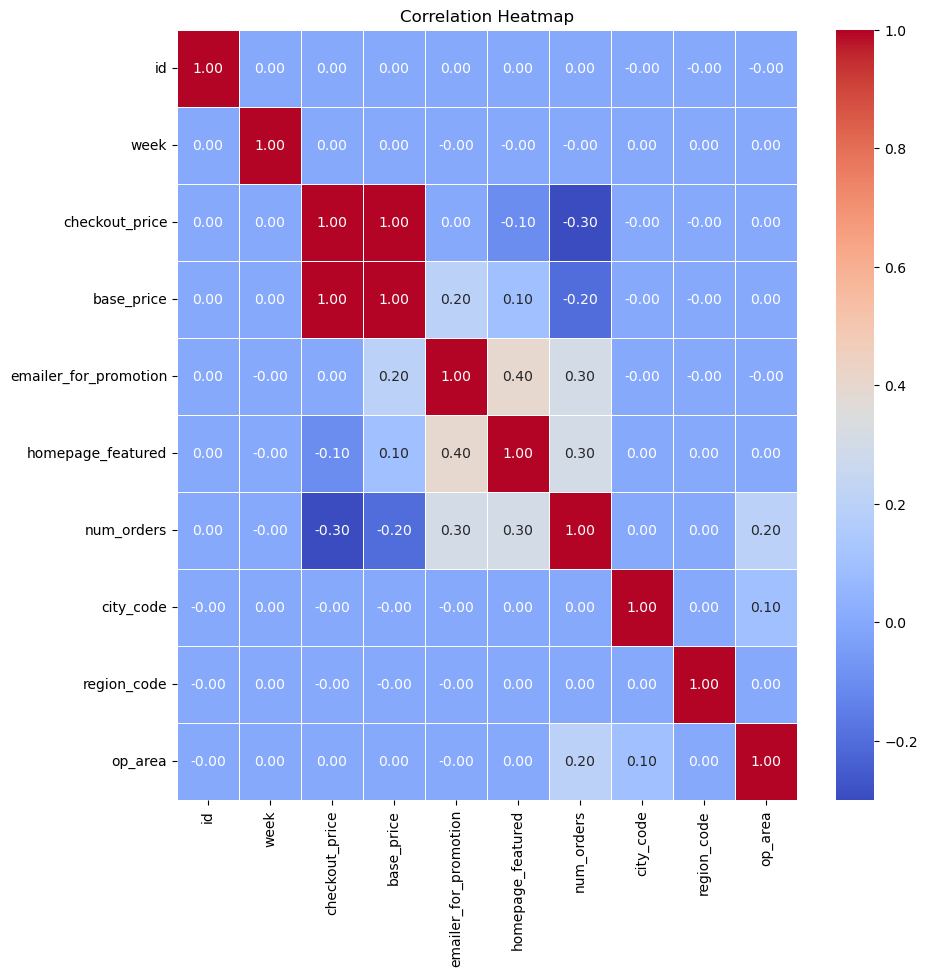

In [20]:
corr = corr_matrix(num_df)

## Bivariate Analysis

In [21]:
# # Number of columns and rows for the subplots
# n_cols = 2  # Number of subplots per row
# n_rows = math.ceil(len(num_col) / n_cols)  # Required number of rows

# # Create subplots
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5 * n_rows))
# axes = axes.flatten()

# # Scatter plots with regression lines for each numerical feature against 'Num_Orders'
# for i, col in enumerate(num_col):
#     sns.regplot(x=num_df[col], y=num_df['num_orders'], ax=axes[i], scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
#     axes[i].set_title(f"Scatter Plot with Trend Line: {col} vs. Num_Orders")
#     axes[i].set_xlabel(col)
#     axes[i].set_ylabel('Number of Orders')

# # Hide unused subplots (if the number of columns isn't a multiple of n_cols)
# for j in range(i + 1, len(axes)):
#     axes[j].set_visible(False)

# plt.tight_layout()
# plt.show()

## Multivariate Analysis

In [22]:
# sns.pairplot(num_df, kind='scatter', diag_kind='kde')
# plt.show()

## Outlier Detection

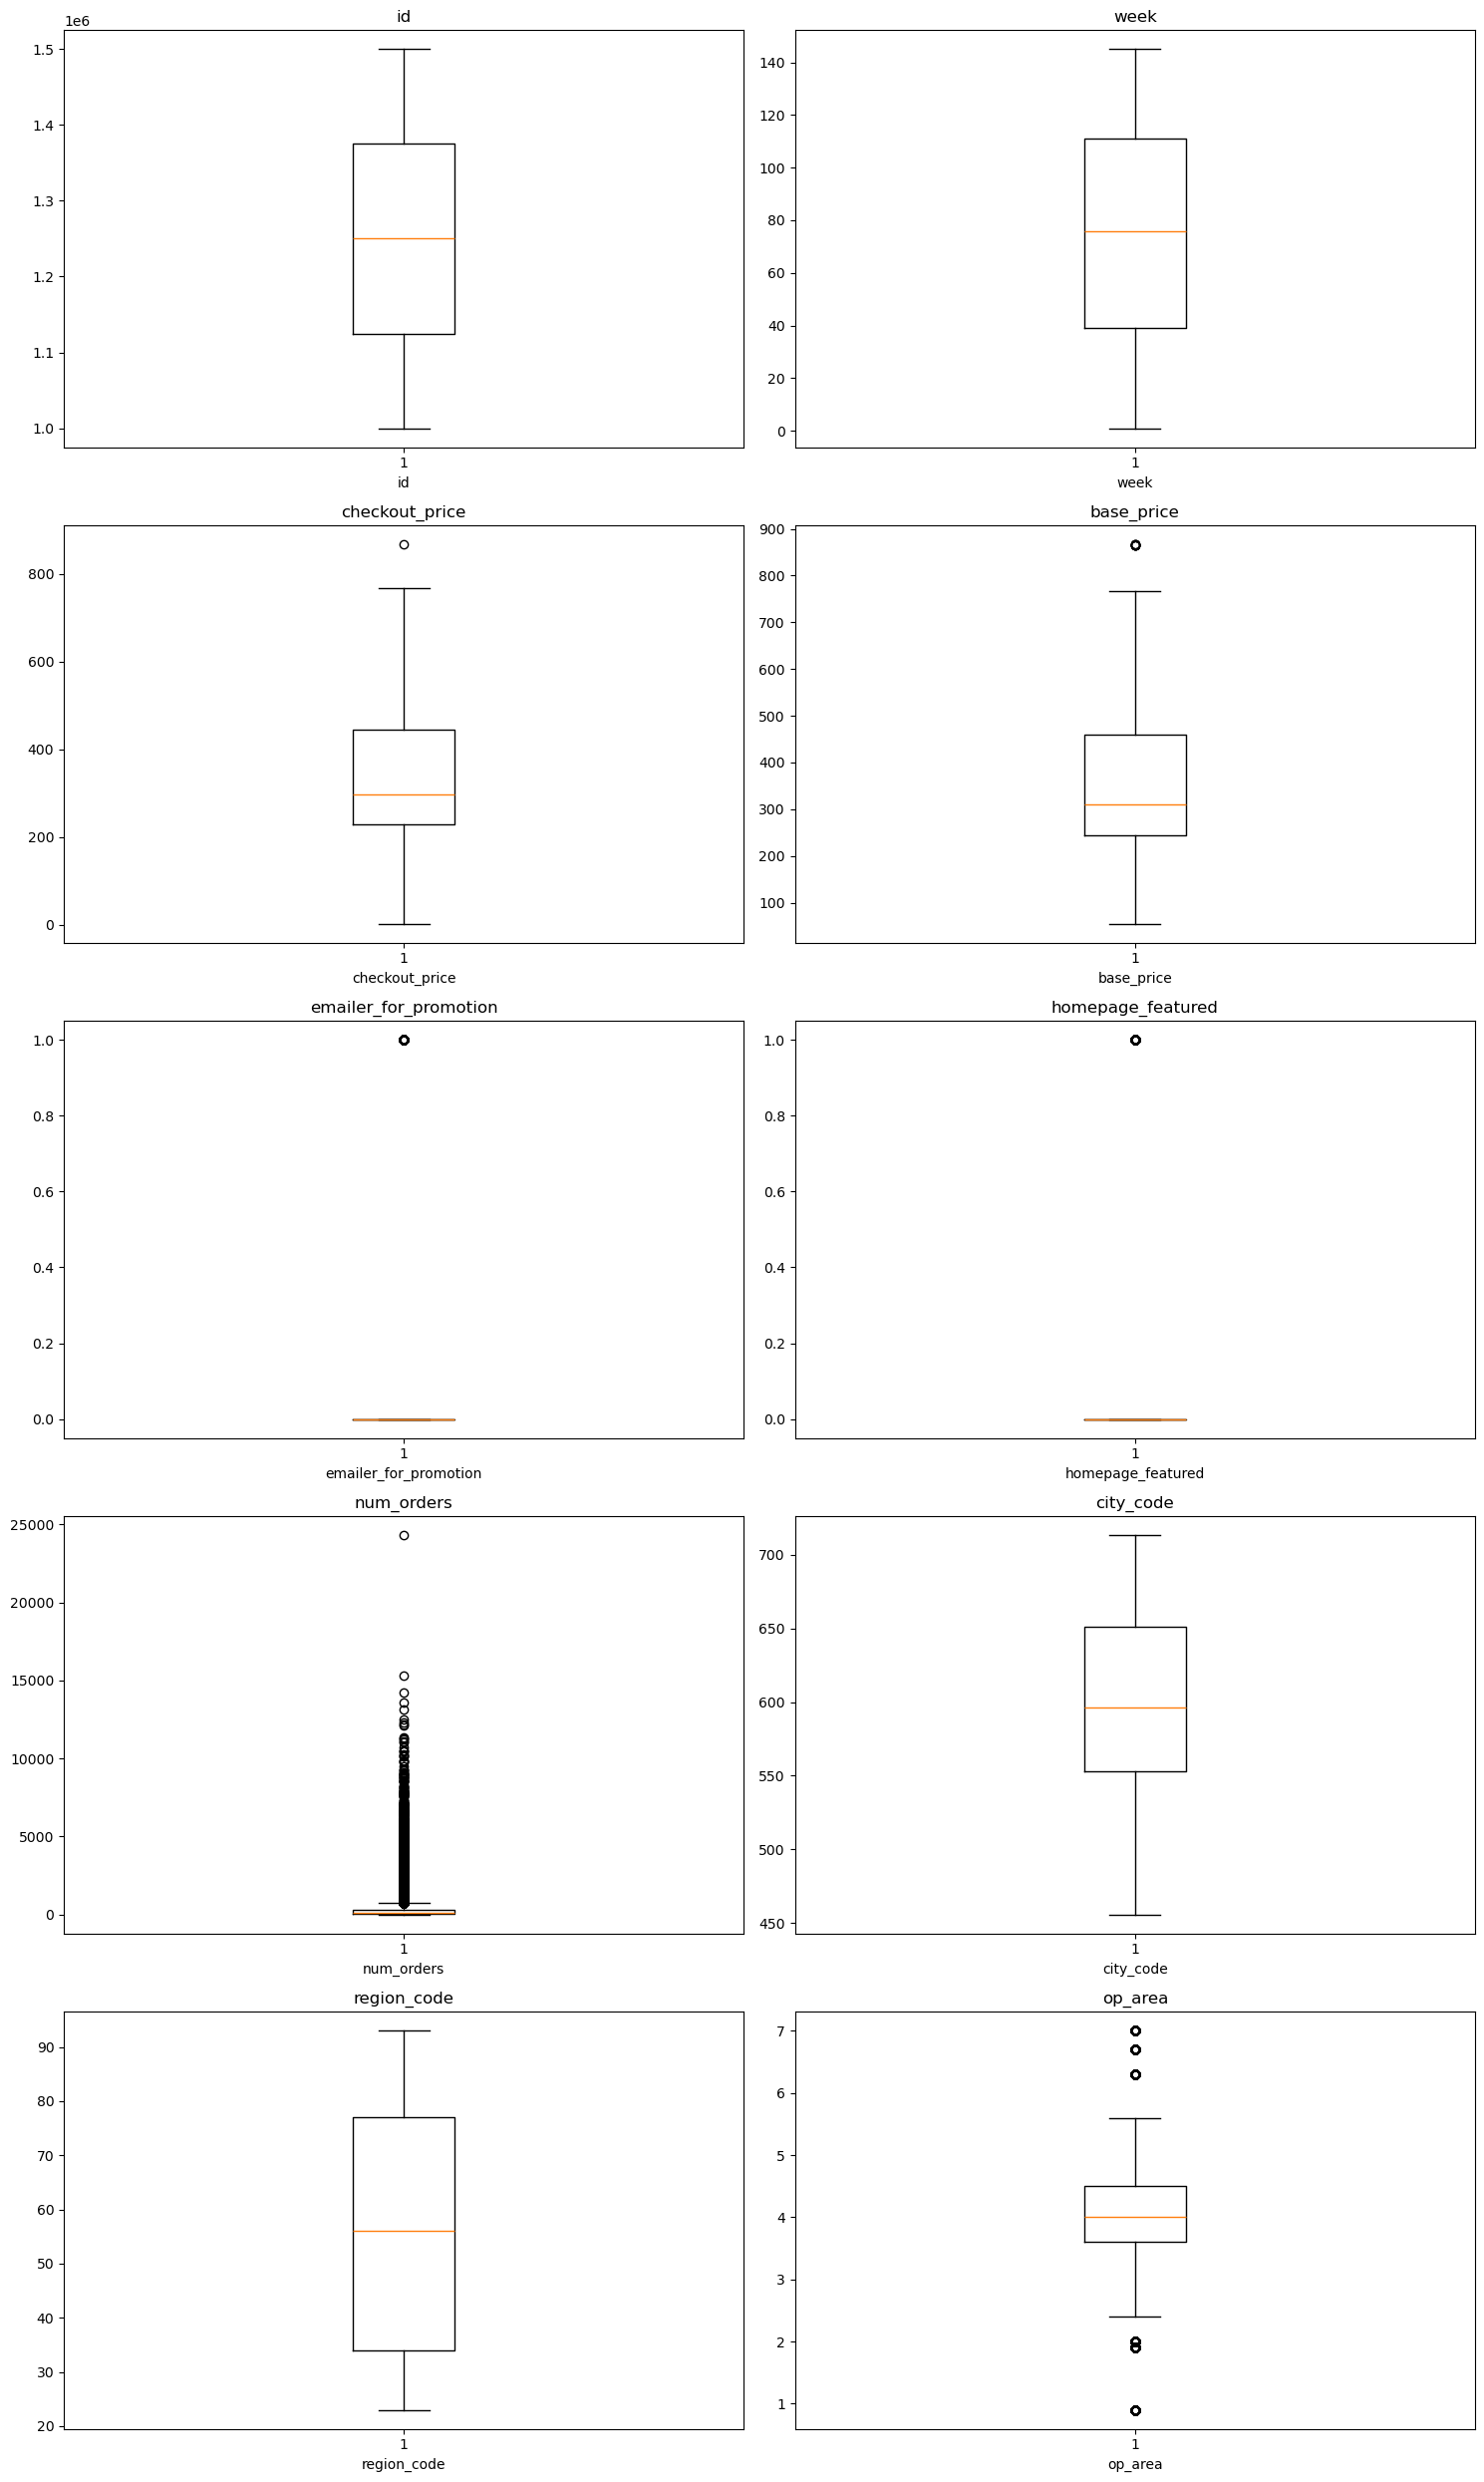

In [23]:
# Number of columns and rows for the subplots
n_cols = 2  # Number of subplots per row
n_rows = math.ceil(len(num_col) / n_cols)  # Required number of rows

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

# Flatten axes array to easily iterate (even if multiple rows)
axes = axes.flatten()

# Plot boxplots for each column
for i, col in enumerate(num_col):
    axes[i].boxplot(num_df[col])
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel(col)

# Hide any unused subplots (if the number of columns isn't a multiple of n_cols)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Outliers detected in **6 columns: 'checkout_price', 'base_price', 'email_for_promotion', 'homepage_featured', 'num_orders' and 'op_area'**  
_However, these outliers are not handled because the data is customer specific_

# Encoding

Catgeorical Columns( 3 ): ['center_type', 'category', 'cuisine']

In [24]:
for col in df_train[['center_type', 'category', 'cuisine']]:
    print(f"Unique values in '{col}' ({df_train[col].nunique()}): \n{df_train[col].unique()}\n")

Unique values in 'center_type' (3): 
['TYPE_C' 'TYPE_B' 'TYPE_A']

Unique values in 'category' (14): 
['Beverages' 'Rice Bowl' 'Starters' 'Pasta' 'Sandwich' 'Biryani' 'Extras'
 'Pizza' 'Seafood' 'Other Snacks' 'Desert' 'Soup' 'Salad' 'Fish']

Unique values in 'cuisine' (4): 
['Thai' 'Indian' 'Italian' 'Continental']



In [25]:
encode_cols = ['center_type', 'category', 'cuisine']
target_encoding_mappings = {} # Dict to store target encoding mappings
for col in encode_cols:
    target_means = df_train.groupby(col)['num_orders'].mean()
    df_train[col] = df_train[col].map(target_means)
    target_encoding_mappings[col] = target_means.to_dict()

with open('target_encoding_mappings.pkl', 'wb') as f:
    pickle.dump(target_encoding_mappings, f)

In [26]:
df_train.head()

,id,week,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
0,1379560,1,136.83,152.29,0,0,177,647,56,206.670097,2.0,316.526116,276.423411
1,1466964,1,136.83,135.83,0,0,270,647,56,206.670097,2.0,316.526116,276.423411
2,1346989,1,134.86,135.86,0,0,189,647,56,206.670097,2.0,316.526116,276.423411
3,1338232,1,339.50,437.53,0,0,54,647,56,206.670097,2.0,316.526116,229.039037
4,1448490,1,243.50,242.50,0,0,40,647,56,206.670097,2.0,316.526116,229.039037


In [27]:
with open('target_encoding_mappings.pkl', 'rb') as f:
    target_encoding_mappings = pickle.load(f)

for col, encoding_map in target_encoding_mappings.items():
    df_test[col] = df_test[col].map(encoding_map)

In [28]:
df_test.head()

,id,week,checkout_price,base_price,emailer_for_promotion,homepage_featured,city_code,region_code,center_type,op_area,category,cuisine
0,1028232,146,158.11,159.11,0,0,647,56,206.670097,2.0,316.526116,276.423411
1,1127204,146,160.11,159.11,0,0,647,56,206.670097,2.0,316.526116,276.423411
2,1212707,146,157.14,159.14,0,0,647,56,206.670097,2.0,316.526116,276.423411
3,1082698,146,162.02,162.02,0,0,647,56,206.670097,2.0,316.526116,229.039037
4,1400926,146,163.93,163.93,0,0,647,56,206.670097,2.0,316.526116,229.039037


# Train-Test Data Split

In [29]:
y_train = df_train['num_orders']
X_train = df_train.drop('num_orders', axis=1)

X_test = df_test

In [30]:
# Initialize the MinMax
scaler = MinMaxScaler()

# Define the numerical columns to scale and categorical columns for merging
numerical_cols = ['id', 'week', 'checkout_price', 'base_price', 'emailer_for_promotion', 
                  'homepage_featured', 'city_code', 'region_code', 'op_area']

categorical_cols = ['center_type', 'category', 'cuisine']

# Fit the scaler on the training set only
X_train_scaled = scaler.fit_transform(X_train[numerical_cols])

# Transform the test set using the fitted scaler
X_test_scaled = scaler.transform(X_test[numerical_cols])

Scaled Training Data Mean (should be close to 0): [0.50019361 0.51228313 0.38140731 0.36847855 0.08115247 0.10919991
 0.56635564 0.48020809 0.52189998]
Scaled Training Data Std Dev (should be close to 1): [0.28870991 0.28836744 0.1771569  0.19818939 0.27306913 0.31188987
 0.25757137 0.25201837 0.17896479]


In [31]:
# Pickle the scaler for future use
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("Scaling complete and scaler has been saved.")

Scaling complete and scaler has been saved.


In [32]:
df_train.describe()

,id,week,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
count,4.565480e+05,456548.000000,456548.000000,456548.000000,456548.000000,456548.00000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000
mean,1.250096e+06,74.768771,332.238933,354.156627,0.081152,0.10920,261.872760,601.553399,56.614566,261.872760,4.083590,261.872760,261.872760
std,1.443548e+05,41.524956,152.939723,160.715914,0.273069,0.31189,395.922798,66.195914,17.641306,36.523942,1.091686,169.227085,70.794147
min,1.000000e+06,1.000000,2.970000,55.350000,0.000000,0.00000,13.000000,456.000000,23.000000,206.670097,0.900000,30.651402,164.545348
25%,1.124999e+06,39.000000,228.950000,243.500000,0.000000,0.00000,54.000000,553.000000,34.000000,262.394456,3.600000,100.895898,229.039037
50%,1.250184e+06,76.000000,296.820000,310.460000,0.000000,0.00000,136.000000,596.000000,56.000000,262.394456,4.000000,293.834169,276.423411
75%,1.375140e+06,111.000000,445.230000,458.870000,0.000000,0.00000,324.000000,651.000000,77.000000,262.394456,4.500000,316.526116,359.347830
max,1.499999e+06,145.000000,866.270000,866.270000,1.000000,1.00000,24299.000000,713.000000,93.000000,318.856145,7.000000,624.822288,359.347830


In [33]:
# Convert scaled numerical columns to DataFrames
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=numerical_cols, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=numerical_cols, index=X_test.index)

# Select the categorical columns from X_train and X_test
X_train_encoded = X_train[categorical_cols]
X_test_encoded = X_test[categorical_cols]

# Combine scaled numerical columns and encoded categorical columns
X_train_combined = pd.concat([X_train_scaled_df, X_train_encoded], axis=1)
X_test_combined = pd.concat([X_test_scaled_df, X_test_encoded], axis=1)

# Verify the combined DataFrame
print(f"Combined Training Data Shape: {X_train_combined.shape}")
print(f"Combined Test Data Shape: {X_test_combined.shape}")

Combined Training Data Shape: (456548, 12)
Combined Test Data Shape: (32573, 12)


In [ ]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_score
from sklearn.metrics import root_mean_squared_log_error
    
# Define models to test
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42)
}

# Define custom scorers
scorers = {
    'RMSLE': make_scorer(root_mean_squared_log_error)
}

results = {}
print("Cross-Validation Results:")
for name, model in models.items():
    results[name] = {}
    for metric, scorer in scorers.items():
        cv_scores = cross_val_score(model, X_train_combined, y_train, cv=5, scoring=scorer)
        mean_cv_score = np.mean(cv_scores)
        results[name][metric] = mean_cv_score

    # Print results for each model
    print(f"{name} -> RMSLE: {results[name]['RMSLE']:.3f}")

Cross-Validation Results:


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:1000: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 139, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 376, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/_param_validation.py", line 213, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py", line 768, in root_mean_squared_log_error
    raise ValueError(
ValueError: Root Mean Squ

Linear Regression -> RMSLE: nan
Decision Tree -> RMSLE: 0.805


In [ ]:
# Train the Random Forest Regressor with the best parameters
rf_model = RandomForestRegressor()

# Train the model on the scaled training data
rf_model.fit(X_train_combined, y_train)

# Predict on the scaled test set
y_pred = rf_model.predict(X_test_combined)

# Evaluate the model
rmsle = RMSLE: {100*rmsle:.3f}"

print(f"RMSLE: {100*rmsle:.3f}")

In [ ]:
# Save the best model to a file
dump(rf_model, 'best_rf_model.joblib')
print("Model saved successfully as 'best_rf_model.joblib'.")

# Load the model from the file
loaded_model = load('best_rf_model.joblib')

# Test the loaded model by predicting on the test set
y_pred_loaded = loaded_model.predict(X_test)
print(f"Loaded Model - RMSLE: {100*RMSLE: {100*rmsle:.3f}":.3f}")